In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_pickle("../Data/countries_clean.plk")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   192 non-null    object 
 1   Capital                   192 non-null    object 
 2   Constitutional_Form       192 non-null    object 
 3   Religion                  192 non-null    object 
 4   Democracy_Score           192 non-null    float64
 5   Democracy_Classification  192 non-null    object 
 6   Development_Status        192 non-null    object 
 7   Latitude                  192 non-null    float64
 8   Longitude                 192 non-null    float64
 9   Area                      192 non-null    int64  
 10  Population                192 non-null    int64  
 11  GDP                       192 non-null    int64  
 12  %Agriculture              192 non-null    float64
 13  GDP_CAPITA                192 non-null    float64
 14  Life_exp  

In [3]:
df.columns

Index(['Country', 'Capital', 'Constitutional_Form', 'Religion',
       'Democracy_Score', 'Democracy_Classification', 'Development_Status',
       'Latitude', 'Longitude', 'Area', 'Population', 'GDP', '%Agriculture',
       'GDP_CAPITA', 'Life_exp', 'lat_pos', 'lon_pos', 'Equatorial',
       'Agriculture_Flag', 'Continent', 'Population_Density', 'Region',
       'Landlocked', 'GDP_per_Area', 'Income_Level', 'Life_Exp_Category'],
      dtype='object')

In [4]:
df_num = df.select_dtypes(include=['number'])
df_num

,Democracy_Score,Latitude,Longitude,Area,Population,GDP,%Agriculture,GDP_CAPITA,Life_exp,GDP_per_Area
0,0.25,34.5328,69.1658,652230,41128771,19101353833,0.58,464.43,64.5,29286
1,6.20,41.3289,19.8178,28748,2775634,15278077447,0.43,5504.36,78.5,531448
2,3.55,36.7764,3.0586,2381741,44903225,169988236398,0.17,3785.66,76.7,71371
3,8.61,42.5000,1.5200,468,79824,3154057987,0.40,39512.65,83.5,6739440
4,4.05,-8.8383,13.2344,1246700,35588987,94635415870,0.48,2659.12,60.8,75909
...,...,...,...,...,...,...,...,...,...,...
187,2.25,10.5000,-66.9333,912050,28301696,482359318768,0.25,17043.48,72.1,528874
188,2.62,21.0300,105.8500,331690,98186856,261921244843,0.39,2667.58,75.3,789657
189,1.95,15.3500,44.2100,555000,33696614,26914402224,0.45,798.73,66.1,48494
190,5.73,-15.4167,28.2833,752618,20017675,23064722446,0.32,1152.22,63.5,30646


In [5]:
df_num.columns

Index(['Democracy_Score', 'Latitude', 'Longitude', 'Area', 'Population', 'GDP',
       '%Agriculture', 'GDP_CAPITA', 'Life_exp', 'GDP_per_Area'],
      dtype='object')

In [6]:
df_selected_num_cols = df[['Democracy_Score', 'Latitude','GDP_CAPITA','%Agriculture','Life_exp']]

In [7]:
df_selected_num_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Democracy_Score  192 non-null    float64
 1   Latitude         192 non-null    float64
 2   GDP_CAPITA       192 non-null    float64
 3   %Agriculture     192 non-null    float64
 4   Life_exp         192 non-null    float64
dtypes: float64(5)
memory usage: 7.6 KB


In [8]:
df_selected_num_cols

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp
0,0.25,34.5328,464.43,0.58,64.5
1,6.20,41.3289,5504.36,0.43,78.5
2,3.55,36.7764,3785.66,0.17,76.7
3,8.61,42.5000,39512.65,0.40,83.5
4,4.05,-8.8383,2659.12,0.48,60.8
...,...,...,...,...,...
187,2.25,10.5000,17043.48,0.25,72.1
188,2.62,21.0300,2667.58,0.39,75.3
189,1.95,15.3500,798.73,0.45,66.1
190,5.73,-15.4167,1152.22,0.32,63.5


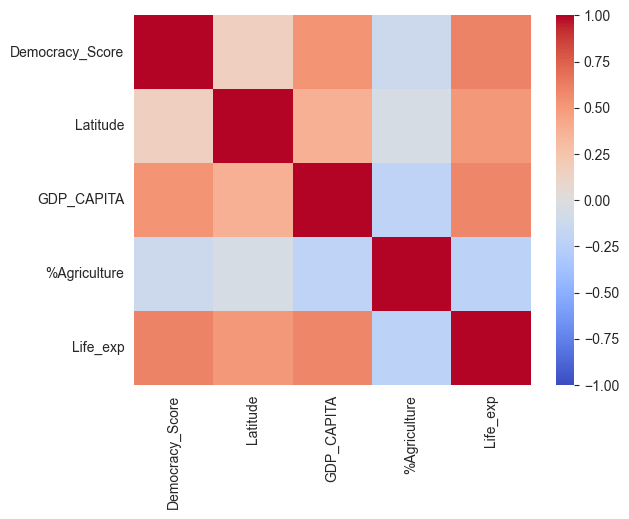

In [9]:
sns.heatmap(df_selected_num_cols.corr(),vmin=-1,vmax=1,cmap='coolwarm');

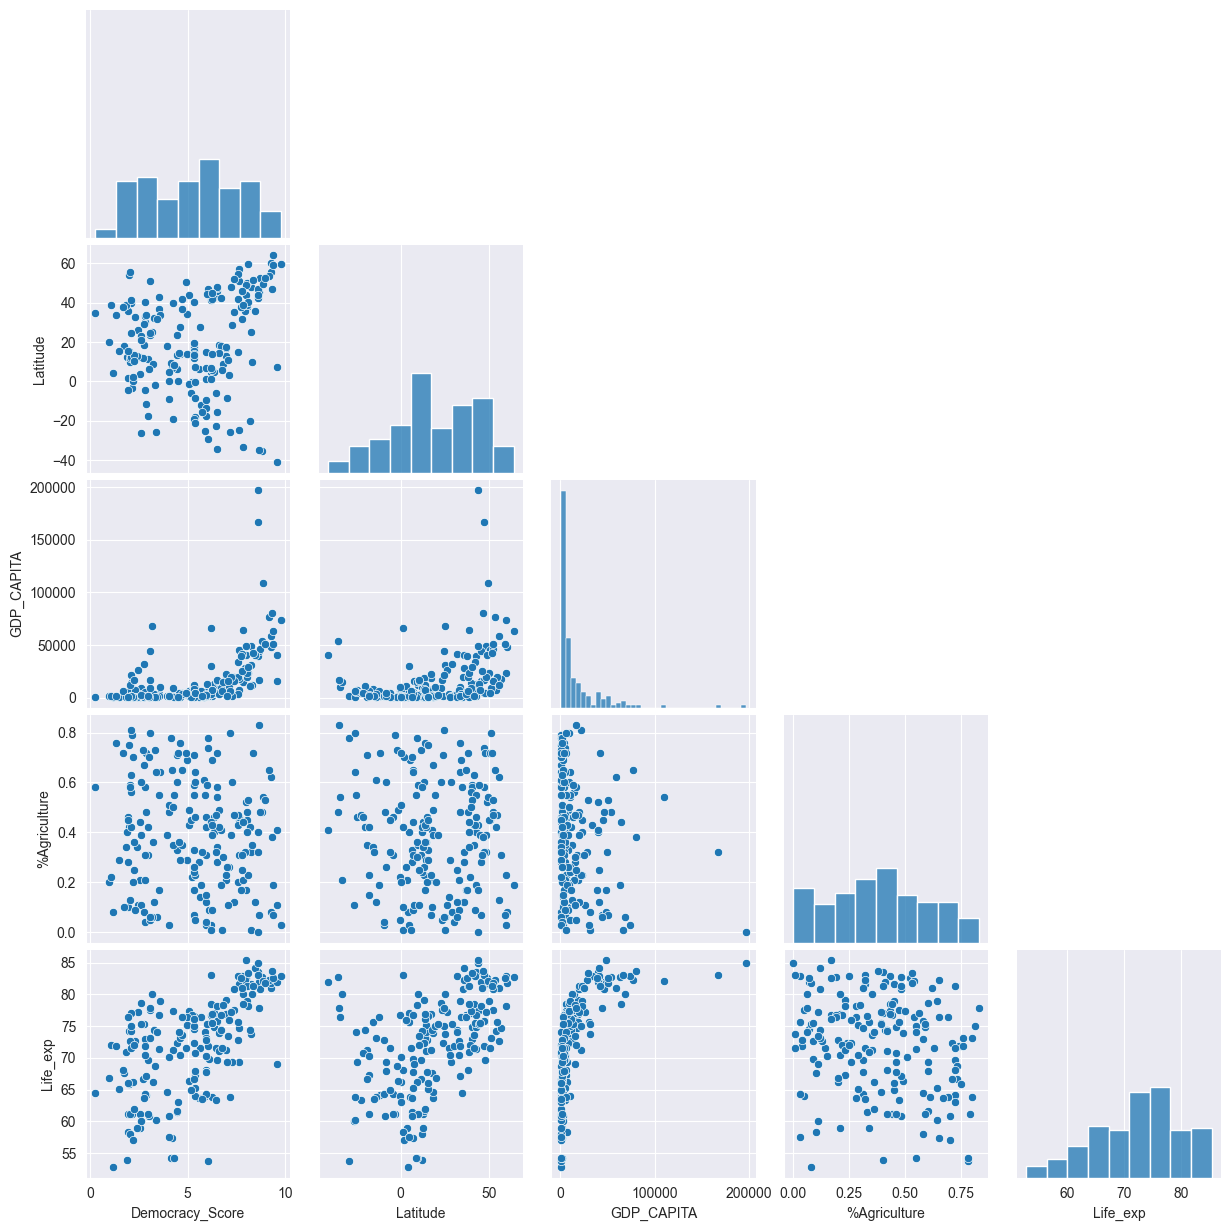

In [10]:
sns.pairplot(df_selected_num_cols,corner=True);

In [11]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()


In [12]:
df_selected_num_cols_std = std.fit_transform(df_selected_num_cols)

In [13]:
df_selected_num_cols_std = pd.DataFrame(df_selected_num_cols_std,columns=df_selected_num_cols.columns)
df_selected_num_cols_std

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp
0,-2.144715,0.644846,-0.590449,0.882187,-1.031280
1,0.382813,0.925372,-0.392174,0.201764,0.827056
2,-0.742893,0.737456,-0.459789,-0.977636,0.588127
3,1.406568,0.973712,0.945736,0.065680,1.490748
4,-0.530496,-1.145400,-0.504108,0.428572,-1.522411
...,...,...,...,...,...
187,-1.295126,-0.347165,0.061783,-0.614743,-0.022469
188,-1.137952,0.087486,-0.503775,0.020318,0.402294
189,-1.422564,-0.146970,-0.577297,0.292487,-0.818898
190,0.183160,-1.416939,-0.563391,-0.297213,-1.164018


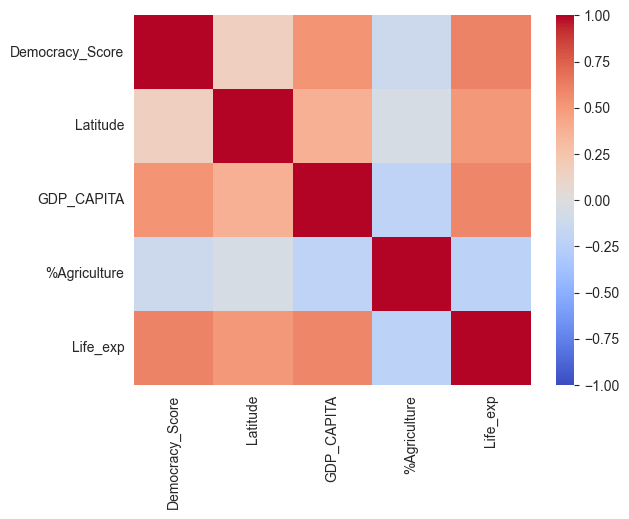

In [14]:
sns.heatmap(df_selected_num_cols_std.corr(),vmin=-1,vmax=1,cmap='coolwarm');

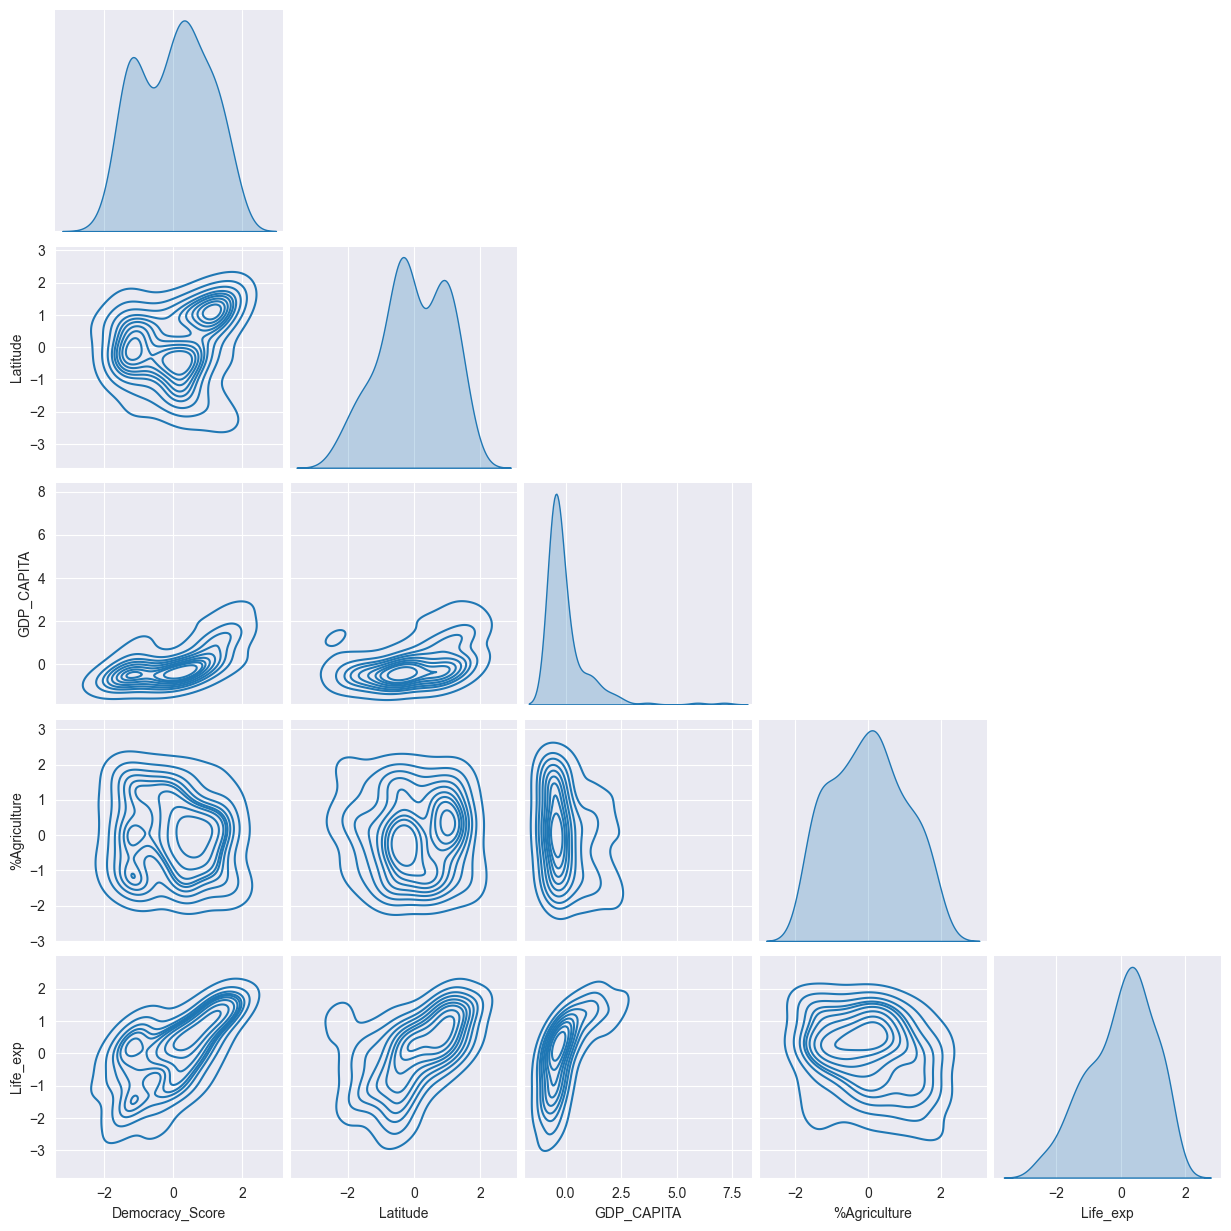

In [15]:
sns.pairplot(df_selected_num_cols_std,corner=True,kind='kde');

In [16]:
from sklearn.preprocessing import MinMaxScaler
norm = MinMaxScaler()

In [17]:
df_selected_num_cols_norm = norm.fit_transform(df_selected_num_cols)
df_selected_num_cols_norm = pd.DataFrame(df_selected_num_cols_norm, columns=df_selected_num_cols.columns)
df_selected_num_cols_norm

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp
0,0.000000,0.719123,0.001173,0.698795,0.358896
1,0.622385,0.783579,0.026785,0.518072,0.788344
2,0.345188,0.740402,0.018051,0.204819,0.733129
3,0.874477,0.794687,0.199610,0.481928,0.941718
4,0.397490,0.307774,0.012326,0.578313,0.245399
...,...,...,...,...,...
187,0.209205,0.491186,0.085425,0.301205,0.592025
188,0.247908,0.591057,0.012369,0.469880,0.690184
189,0.177824,0.537185,0.002871,0.542169,0.407975
190,0.573222,0.245382,0.004668,0.385542,0.328221


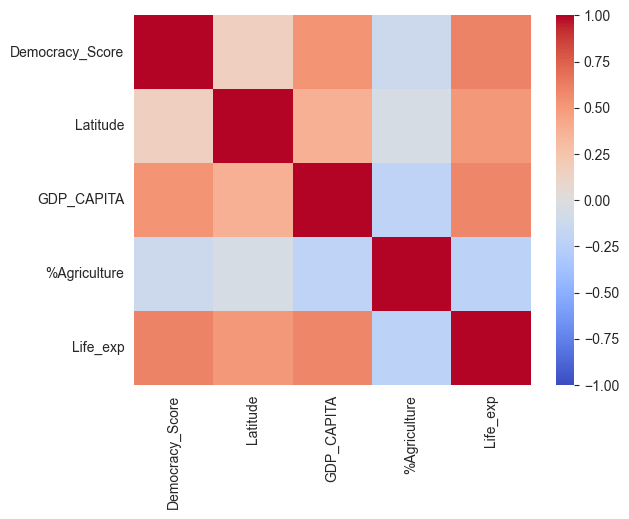

In [18]:
sns.heatmap(df_selected_num_cols_norm.corr(),vmin=-1,vmax=1,cmap='coolwarm');

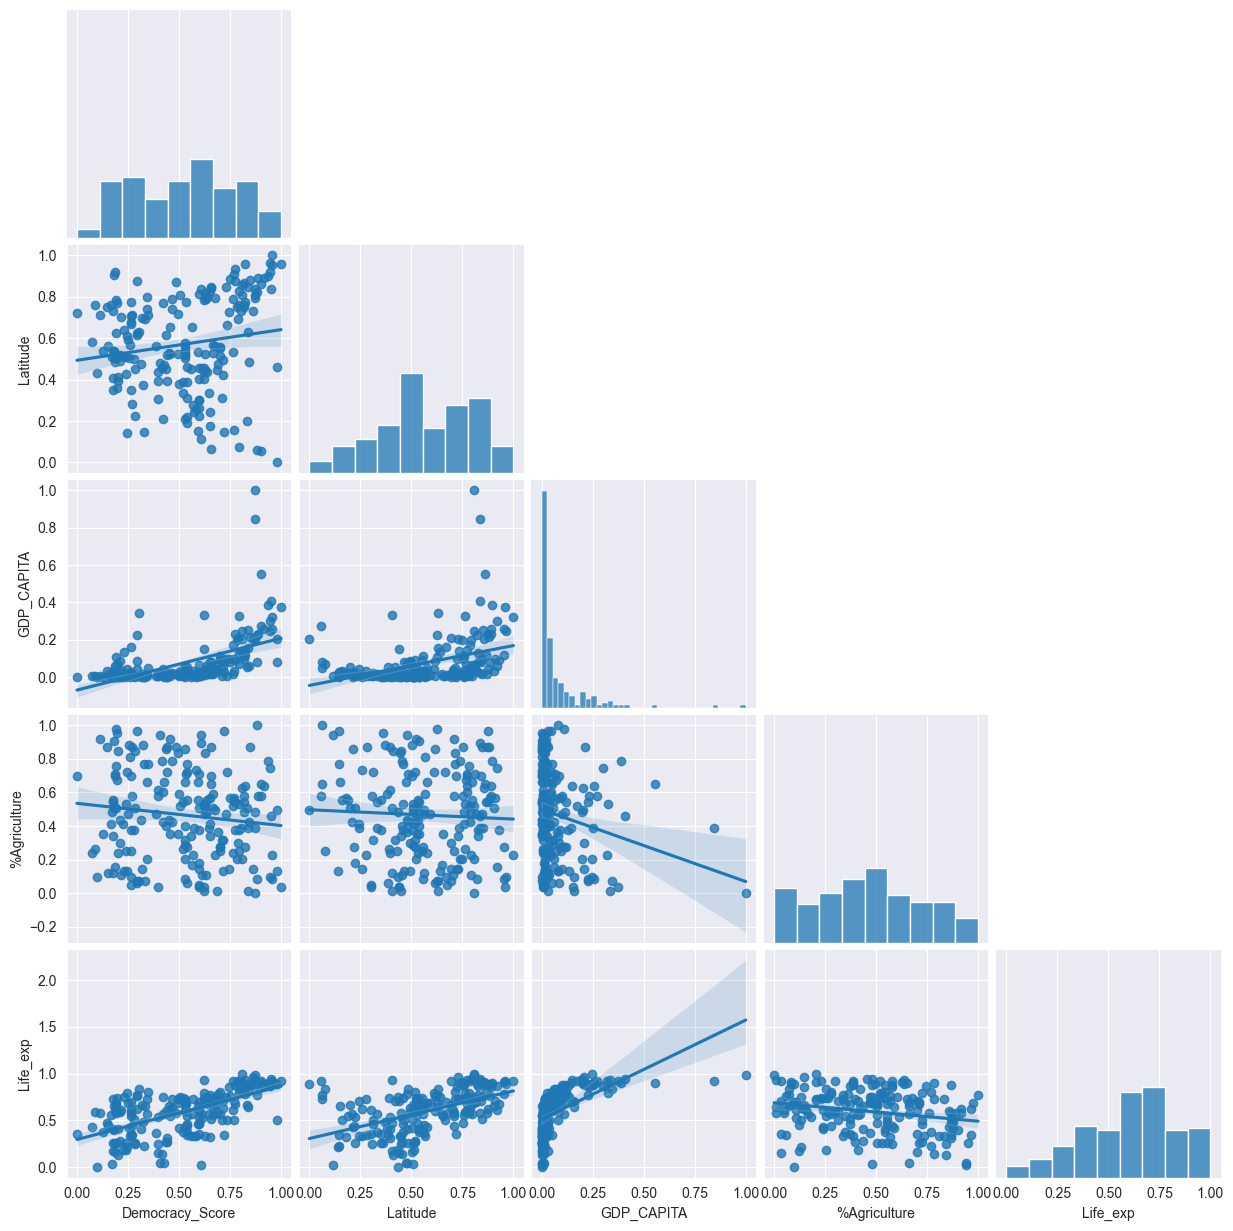

In [19]:
sns.pairplot(df_selected_num_cols_norm,kind='reg', corner=True);

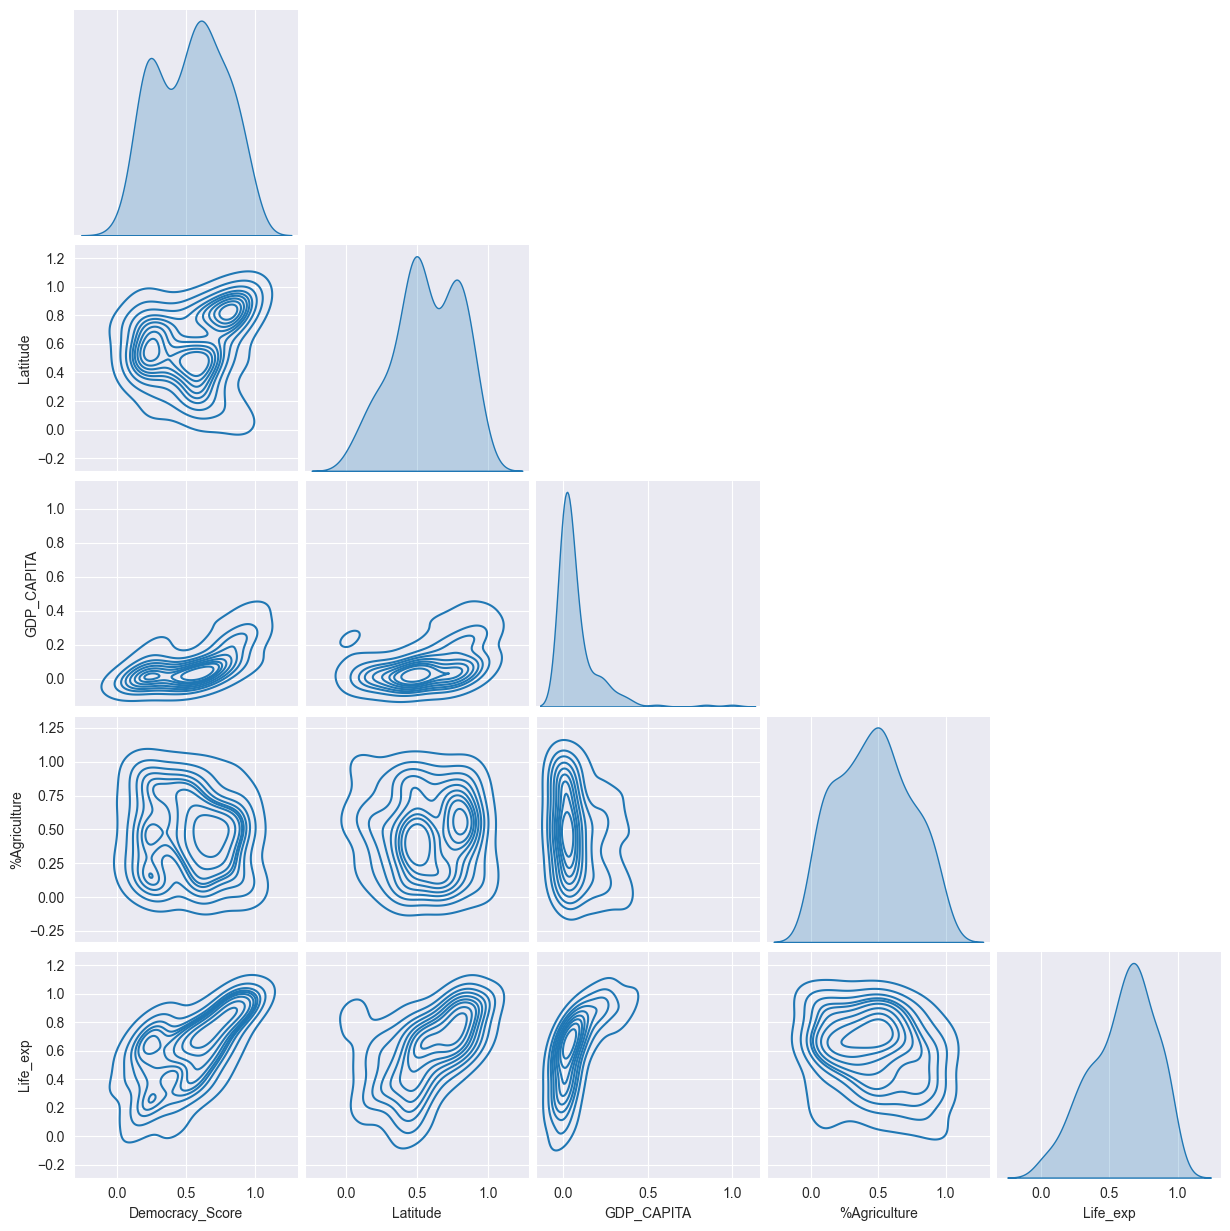

In [20]:
sns.pairplot(df_selected_num_cols_norm,kind='kde',corner=True);

#### Clustering

In [21]:
from sklearn.cluster import KMeans

  File "c:\Users\Lenovo\miniconda3\envs\pycaret39\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


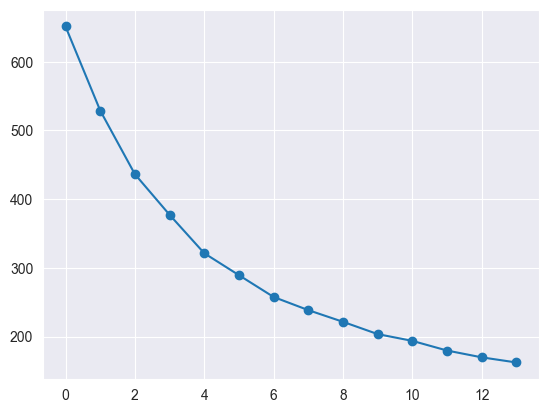

In [22]:
inertia_values = []
for k in range(2,16):
    kmeans=KMeans(n_clusters=k,n_init=10,random_state=42)
    kmeans.fit(df_selected_num_cols_std)
    inertia_values.append(kmeans.inertia_)
pd.Series(inertia_values).plot(marker='o');

In [23]:
kmeans4 = KMeans(n_clusters=4, n_init='auto', random_state=42)
kmeans4.fit(df_selected_num_cols_norm)

KMeans(n_clusters=4, random_state=42)

In [24]:
kmeans4.labels_

array([3, 2, 0, 2, 1, 0, 1, 3, 0, 2, 3, 0, 0, 3, 0, 3, 2, 0, 1, 0, 0, 3,
       1, 0, 0, 3, 1, 1, 0, 0, 1, 2, 1, 1, 0, 3, 0, 1, 1, 1, 2, 1, 2, 3,
       2, 2, 2, 1, 0, 3, 0, 0, 3, 0, 1, 2, 0, 1, 0, 2, 2, 0, 1, 3, 2, 1,
       2, 0, 0, 1, 1, 0, 1, 0, 3, 2, 3, 0, 3, 0, 2, 2, 2, 0, 2, 0, 3, 1,
       1, 0, 3, 0, 2, 3, 1, 0, 0, 2, 2, 2, 1, 1, 0, 1, 2, 1, 1, 0, 3, 0,
       3, 2, 3, 2, 3, 1, 0, 1, 0, 0, 2, 0, 3, 1, 1, 3, 0, 2, 0, 3, 0, 0,
       0, 0, 1, 0, 0, 2, 2, 0, 3, 0, 1, 0, 0, 0, 0, 2, 1, 3, 1, 2, 1, 0,
       2, 2, 0, 1, 1, 2, 0, 2, 0, 1, 0, 2, 2, 3, 3, 1, 0, 0, 1, 1, 0, 3,
       3, 3, 1, 1, 3, 0, 2, 2, 1, 3, 0, 0, 3, 1, 1, 1])

In [25]:
df_selected_num_cols['country']=df.Country
df_selected_num_cols['cluster']=pd.Series(kmeans4.labels_,name='cluster')
df_selected_cols_clust = df_selected_num_cols
df_selected_cols_clust

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp,country,cluster
0,0.25,34.5328,464.43,0.58,64.5,Afghanistan,3
1,6.20,41.3289,5504.36,0.43,78.5,Albania,2
2,3.55,36.7764,3785.66,0.17,76.7,Algeria,0
3,8.61,42.5000,39512.65,0.40,83.5,Andorra,2
4,4.05,-8.8383,2659.12,0.48,60.8,Angola,1
...,...,...,...,...,...,...,...
187,2.25,10.5000,17043.48,0.25,72.1,Venezuela,0
188,2.62,21.0300,2667.58,0.39,75.3,Vietnam,3
189,1.95,15.3500,798.73,0.45,66.1,Yemen,1
190,5.73,-15.4167,1152.22,0.32,63.5,Zambia,1


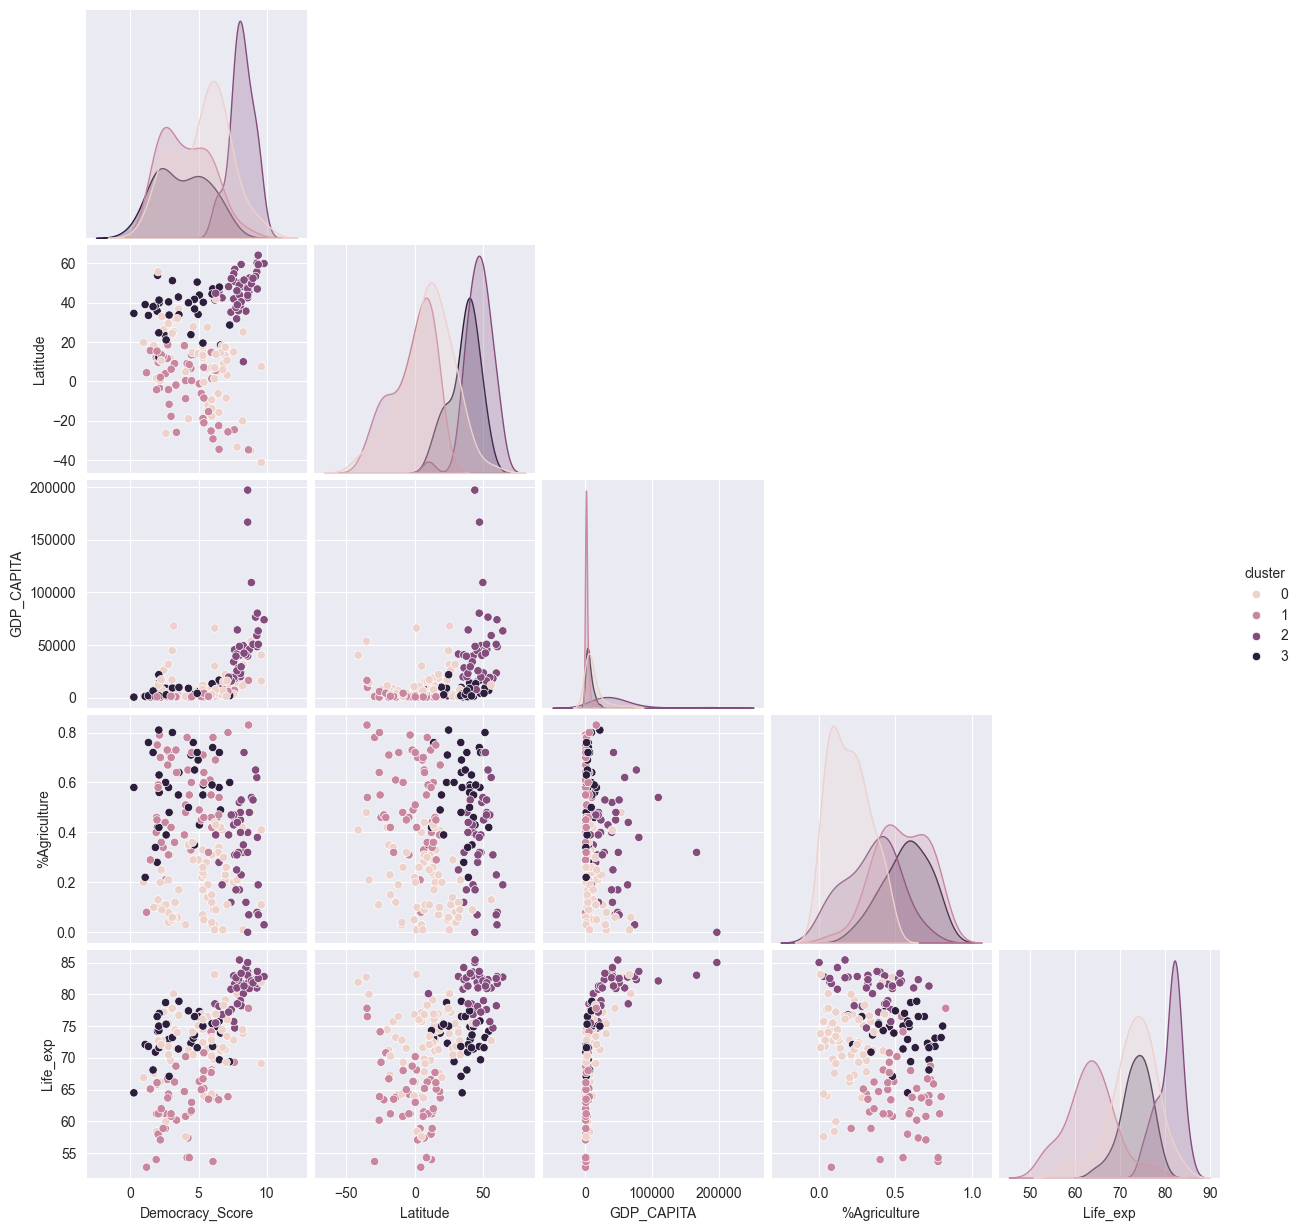

In [26]:
sns.pairplot(df_selected_cols_clust,corner=True,hue='cluster');

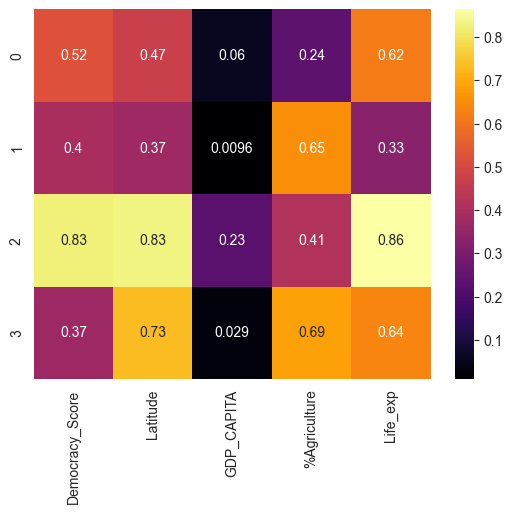

In [27]:
sns.heatmap(pd.DataFrame(kmeans4.cluster_centers_,columns=df_selected_num_cols_norm.columns),annot=True,cmap='inferno');

In [28]:
df_selected_cols_clust.cluster.value_counts()

cluster
0    66
1    50
2    41
3    35
Name: count, dtype: int64

In [29]:
df_selected_cols_clust.query("country == 'Norway'")

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp,country,cluster
127,9.81,59.91,73910.02,0.03,82.8,Norway,2


In [30]:
df_selected_cols_clust.query("cluster == 0")

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp,country,cluster
2,3.550,36.7764,3785.66,0.17,76.7,Algeria,0
5,6.965,17.1211,18426.88,0.21,76.9,Antigua and Barbuda,0
8,8.850,-35.2931,53608.07,0.48,82.7,Australia,0
11,8.270,25.0781,31286.59,0.01,73.8,The Bahamas,0
12,2.450,26.2250,26201.06,0.11,77.2,Bahrain,0
...,...,...,...,...,...,...,...
171,7.030,-8.5536,1247.70,0.26,69.3,Timor-Leste,0
174,7.090,10.6500,15741.03,0.11,73.4,Trinidad and Tobago,0
181,3.070,24.4511,44607.19,0.06,77.8,United Arab Emirates,0
186,5.970,-17.7333,2806.69,0.15,70.3,Vanuatu,0


In [31]:

df_selected_cols_clust.query("cluster == 1")

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp,country,cluster
4,4.050,-8.8383,2659.12,0.48,60.8,Angola,1
6,6.510,-34.6000,9725.64,0.54,76.5,Argentina,1
18,4.440,6.4833,1077.72,0.33,61.5,Benin,1
22,7.630,-24.6500,6972.79,0.46,69.3,Botswana,1
26,2.550,12.3686,694.45,0.44,61.2,Burkina Faso,1
27,2.130,-3.4283,233.70,0.79,61.2,Burundi,1
30,2.560,3.8578,1388.54,0.21,58.9,Cameroon,1
32,1.180,4.3600,397.97,0.08,52.8,Central African Republic,1
33,1.890,12.1100,638.42,0.40,54.0,Chad,1
37,2.840,-11.7036,1417.02,0.72,64.1,Comoros,1


In [32]:

df_selected_cols_clust.query("cluster == 2")

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp,country,cluster
1,6.200,41.3289,5504.36,0.43,78.5,Albania,2
3,8.610,42.5000,39512.65,0.40,83.5,Andorra,2
9,8.280,48.2000,49357.30,0.32,81.6,Austria,2
16,7.640,50.8467,45384.05,0.45,81.6,Belgium,2
31,8.690,45.4247,44603.90,0.07,81.9,Canada,2
40,8.290,9.9325,11923.56,0.35,80.1,Costa Rica,2
42,6.500,45.8100,15676.06,0.28,78.1,Croatia,2
44,7.380,35.1725,19628.35,0.12,80.8,Cyprus,2
45,8.080,50.0800,23417.02,0.45,79.0,Czech Republic,2
46,9.280,55.6761,58965.92,0.62,81.0,Denmark,2


In [33]:

df_selected_cols_clust.query("cluster == 3")

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp,country,cluster
0,0.25,34.5328,464.43,0.58,64.5,Afghanistan,3
7,5.35,40.1800,4917.44,0.59,74.9,Armenia,3
10,2.80,40.3800,3853.26,0.58,72.9,Azerbaijan,3
13,4.44,23.7289,1767.50,0.71,72.3,Bangladesh,3
15,1.99,53.9000,6850.09,0.42,74.2,Belarus,3
21,5.06,43.8564,6200.00,0.43,77.3,Bosnia and Herzegovina,3
25,6.34,42.6979,13302.20,0.46,74.9,Bulgaria,3
35,2.11,39.9000,14098.82,0.56,77.0,China,3
43,2.58,23.1300,8920.91,0.60,78.7,Cuba,3
49,6.62,18.4764,7920.80,0.49,73.9,Dominican Republic,3


In [34]:

df_selected_cols_clust.query("cluster == 1")

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp,country,cluster
4,4.050,-8.8383,2659.12,0.48,60.8,Angola,1
6,6.510,-34.6000,9725.64,0.54,76.5,Argentina,1
18,4.440,6.4833,1077.72,0.33,61.5,Benin,1
22,7.630,-24.6500,6972.79,0.46,69.3,Botswana,1
26,2.550,12.3686,694.45,0.44,61.2,Burkina Faso,1
27,2.130,-3.4283,233.70,0.79,61.2,Burundi,1
30,2.560,3.8578,1388.54,0.21,58.9,Cameroon,1
32,1.180,4.3600,397.97,0.08,52.8,Central African Republic,1
33,1.890,12.1100,638.42,0.40,54.0,Chad,1
37,2.840,-11.7036,1417.02,0.72,64.1,Comoros,1


In [35]:
df['Cluster']=df_selected_cols_clust.cluster


In [36]:
df.to_csv("../Data/country_clusters.csv",index=False)

In [37]:
df_selected_num_cols_std

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp
0,-2.144715,0.644846,-0.590449,0.882187,-1.031280
1,0.382813,0.925372,-0.392174,0.201764,0.827056
2,-0.742893,0.737456,-0.459789,-0.977636,0.588127
3,1.406568,0.973712,0.945736,0.065680,1.490748
4,-0.530496,-1.145400,-0.504108,0.428572,-1.522411
...,...,...,...,...,...
187,-1.295126,-0.347165,0.061783,-0.614743,-0.022469
188,-1.137952,0.087486,-0.503775,0.020318,0.402294
189,-1.422564,-0.146970,-0.577297,0.292487,-0.818898
190,0.183160,-1.416939,-0.563391,-0.297213,-1.164018


In [38]:
from scipy.cluster.hierarchy import linkage, dendrogram


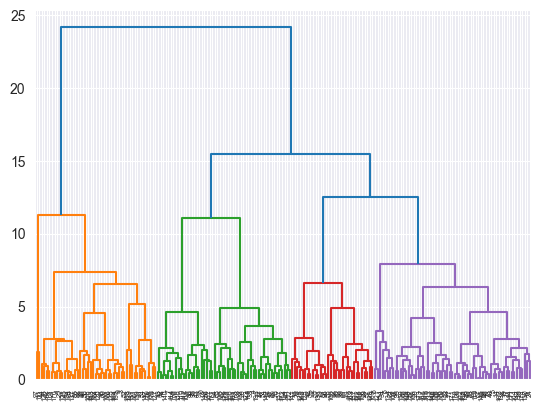

In [39]:
linkage_matrix = linkage(df_selected_num_cols_std, method='ward')
dendrogram_info = dendrogram(linkage_matrix, color_threshold=12)

In [40]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')

In [41]:
agg.fit(df_selected_num_cols_std)

AgglomerativeClustering(n_clusters=4)

In [42]:
df_selected_num_cols.cluster=pd.Series(agg.labels_,name='clusters')

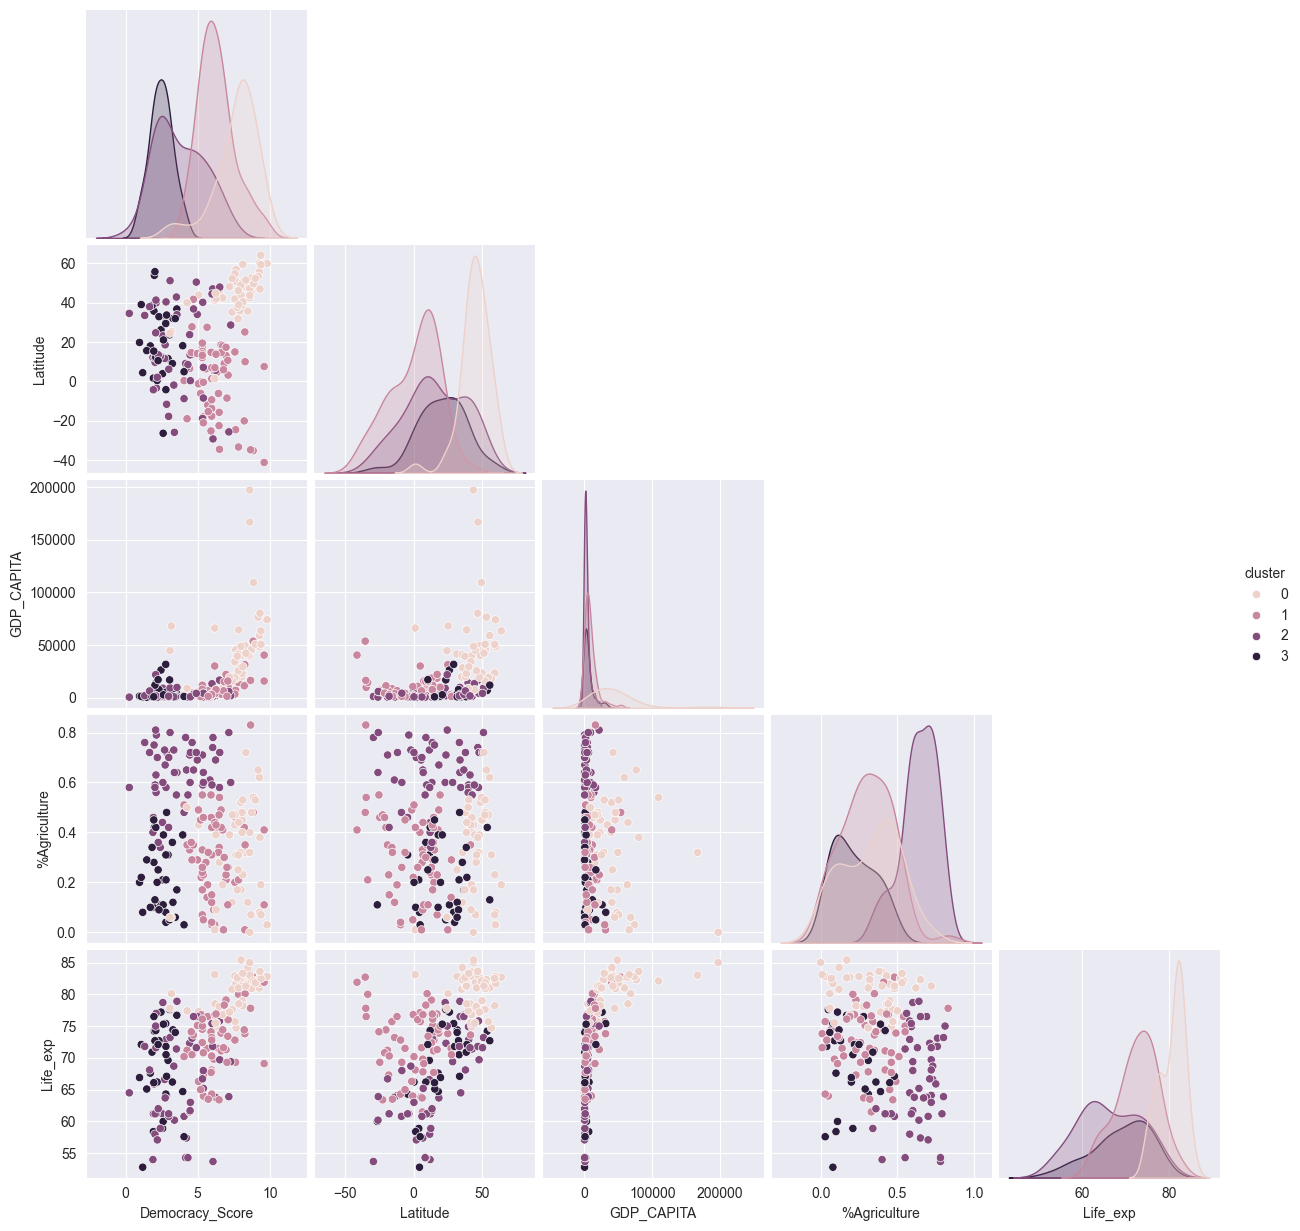

In [43]:
sns.pairplot(df_selected_num_cols,corner=True,hue='cluster');

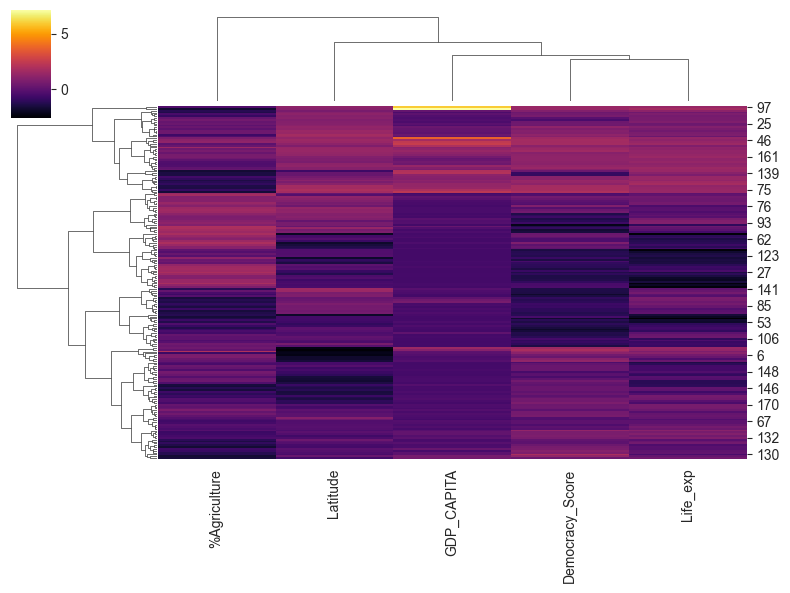

In [44]:
sns.clustermap(df_selected_num_cols_std, method='ward', figsize=(8,6), cmap='inferno', xticklabels=df_selected_num_cols.columns)
plt.show()

In [45]:
from sklearn.cluster import DBSCAN

In [46]:
dbscan = DBSCAN(eps=1.7, min_samples=5)

In [47]:
dbscan.fit(df_selected_num_cols_std)

DBSCAN(eps=1.7)

In [48]:
pd.Series(dbscan.labels_,name='outlier')

0      0
1      0
2      0
3      0
4      0
      ..
187    0
188    0
189    0
190    0
191    0
Name: outlier, Length: 192, dtype: int64

In [49]:
df_selected_num_cols['outlier']=pd.Series(dbscan.labels_,name='outlier')

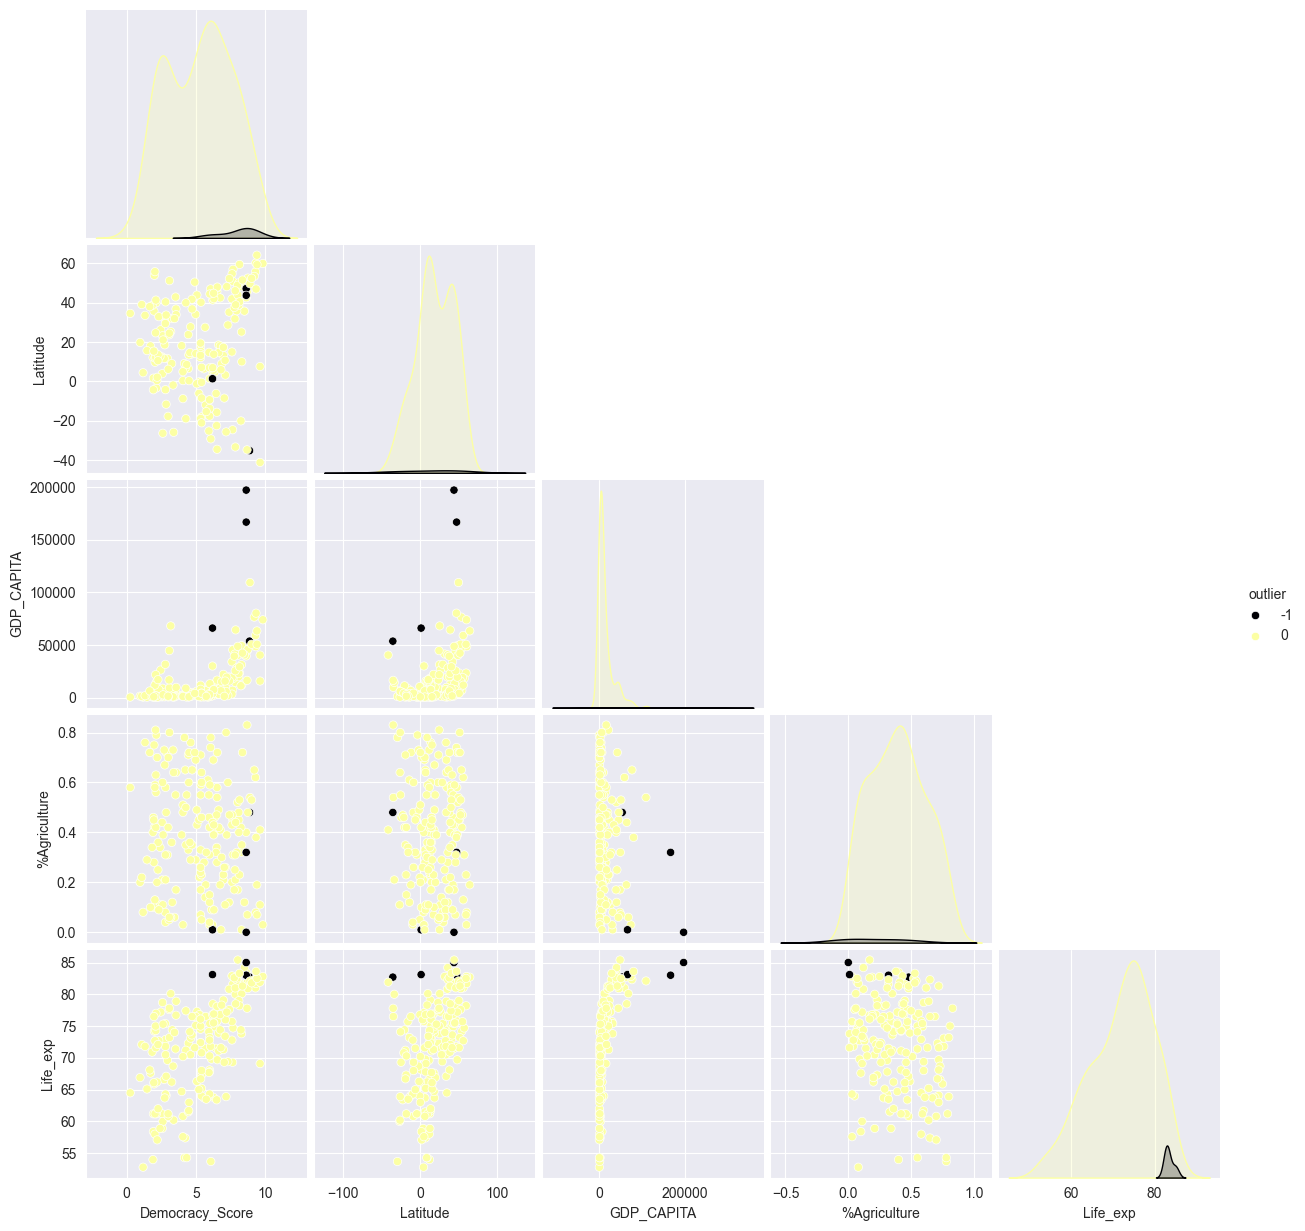

In [50]:
sns.pairplot(df_selected_num_cols.drop(columns='cluster'),corner=True,hue='outlier',palette='inferno');

In [51]:
df['outlier']=pd.Series(dbscan.labels_,name='outlier')

In [52]:
df

,Country,Capital,Constitutional_Form,Religion,Democracy_Score,Democracy_Classification,Development_Status,Latitude,Longitude,Area,...,Agriculture_Flag,Continent,Population_Density,Region,Landlocked,GDP_per_Area,Income_Level,Life_Exp_Category,Cluster,outlier
0,Afghanistan,Kabul,Islamic Republic (Provisional),Islam,0.25,Authoritarian,Developing,34.5328,69.1658,652230,...,Yes,Asia,63.1,South Asia,Yes,29286,Low,Low,3,0
1,Albania,Tirana,Parliamentary Republic,Islam,6.20,Flawed Democracy,Developing,41.3289,19.8178,28748,...,Yes,Europe,96.6,Central Europe,No,531448,Upper-Middle,High,2,0
2,Algeria,Algiers,Presidential Republic,Islam,3.55,Authoritarian,Developing,36.7764,3.0586,2381741,...,No,Africa,18.9,North Africa,No,71371,Lower-Middle,High,0,0
3,Andorra,Andorra la Vella,Parliamentary Co-Principality,Christianity,8.61,Full Democracy,Developed,42.5000,1.5200,468,...,Yes,Europe,170.6,Western Europe,Yes,6739440,High,High,2,0
4,Angola,Luanda,Presidential Republic,Christianity,4.05,Hybrid Regime,Developing,-8.8383,13.2344,1246700,...,Yes,Africa,28.5,East Africa,No,75909,Lower-Middle,Low,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,Venezuela,Caracas,Federal Presidential Republic,Christianity,2.25,Authoritarian,Developing,10.5000,-66.9333,912050,...,Yes,South America,31,Northern South America,No,528874,High,Medium,0,0
188,Vietnam,Hanoi,One-Party Socialist Republic,Unaffiliated,2.62,Authoritarian,Developing,21.0300,105.8500,331690,...,Yes,Asia,296,Southeast Asia,No,789657,Lower-Middle,High,3,0
189,Yemen,Sanaa,Provisional Government,Islam,1.95,Authoritarian,Developing,15.3500,44.2100,555000,...,Yes,Asia,60.7,Western Asia/Middle East,No,48494,Low,Medium,1,0
190,Zambia,Lusaka,Presidential Republic,Christianity,5.73,Hybrid Regime,Developing,-15.4167,28.2833,752618,...,Yes,Africa,26.6,Southern Africa,Yes,30646,Lower-Middle,Low,1,0


In [53]:
df.outlier=np.where(df.outlier == -1, 'yes', 'no')

In [54]:
df.query("outlier == 'yes'")

,Country,Capital,Constitutional_Form,Religion,Democracy_Score,Democracy_Classification,Development_Status,Latitude,Longitude,Area,...,Agriculture_Flag,Continent,Population_Density,Region,Landlocked,GDP_per_Area,Income_Level,Life_Exp_Category,Cluster,outlier
8,Australia,Canberra,Federal Constitutional Monarchy,Christianity,8.85,Full Democracy,Developed,-35.2931,149.1269,7692024,...,Yes,Oceania,3.4,Australia/New Zealand,No,181055,High,High,0,yes
97,Liechtenstein,Vaduz,Constitutional Monarchy,Christianity,8.61,Full Democracy,Developed,47.1400,9.5200,160,...,Yes,Europe,245.8,Western Europe,Yes,40955367,High,High,2,yes
111,Monaco,Monaco City,Constitutional Monarchy,Christianity,8.61,Full Democracy,Developed,43.7310,7.4248,2,...,No,Europe,"18,234.50",Western Europe,No,3592422097,High,High,2,yes
153,Singapore,Singapore,Parliamentary Republic,Buddhism,6.18,Flawed Democracy,Developed,1.2900,103.8500,719,...,No,Asia,"7,840.10",Southeast Asia,No,517472222,High,High,0,yes


In [55]:
df.to_csv("../Data/country_clusters.csv",index=False)

In [56]:
from sklearn.metrics import silhouette_score
silhouette_score(df_selected_num_cols_std,dbscan.labels_,metric='euclidean',sample_size=None)

0.4832508881038396

In [57]:

import pycaret
print(pycaret.__version__)


3.3.2


In [58]:
from pycaret.clustering import *

In [59]:
exp = setup(data=df_selected_num_cols_std, session_id=123)

,Description,Value
0,Session id,123
1,Original data shape,"(192, 5)"
2,Transformed data shape,"(192, 5)"
3,Numeric features,5
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,CPU Jobs,-1
9,Use GPU,False


In [60]:
kmeans = create_model('kmeans')

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2675,75.2160,1.2486,0,0,0


In [61]:
plot_model(kmeans, plot='cluster') 

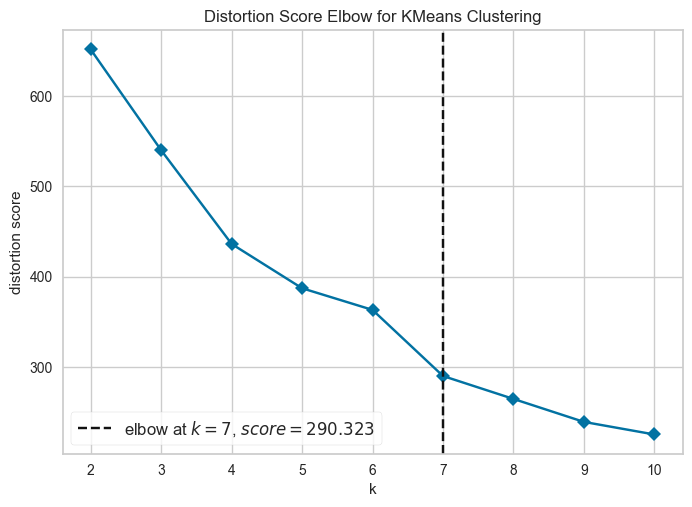

In [62]:
plot_model(kmeans, plot='elbow')  

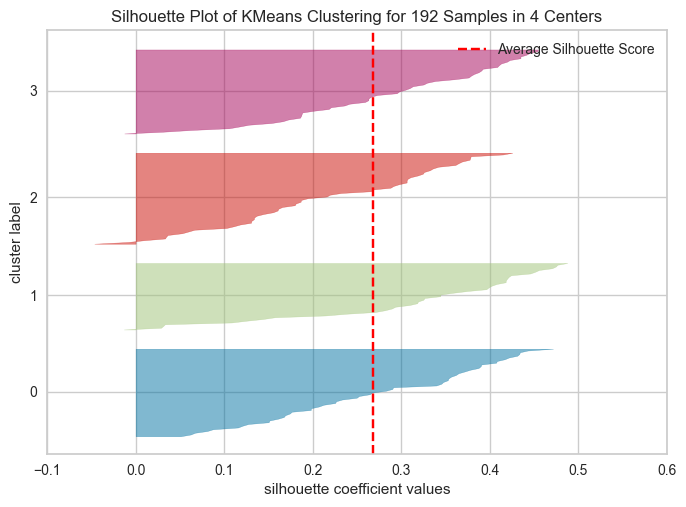

In [63]:
plot_model(kmeans, plot='silhouette')    # silhouette plot [1]

In [64]:
labeled_train = assign_model(kmeans)

In [65]:
labeled_train

,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp,Cluster
0,-2.144716,0.644846,-0.590449,0.882187,-1.031280,Cluster 2
1,0.382813,0.925372,-0.392174,0.201764,0.827056,Cluster 2
2,-0.742893,0.737456,-0.459789,-0.977636,0.588127,Cluster 2
3,1.406568,0.973712,0.945736,0.065680,1.490748,Cluster 1
4,-0.530496,-1.145400,-0.504108,0.428572,-1.522411,Cluster 3
...,...,...,...,...,...,...
187,-1.295126,-0.347165,0.061783,-0.614743,-0.022469,Cluster 2
188,-1.137952,0.087486,-0.503775,0.020318,0.402294,Cluster 2
189,-1.422565,-0.146970,-0.577297,0.292487,-0.818898,Cluster 3
190,0.183160,-1.416939,-0.563391,-0.297213,-1.164018,Cluster 3


In [67]:

from pycaret.anomaly import *

data = df_selected_num_cols_std  

# 1) setup (no target label in anomaly detection)
exp = setup(data=data, session_id=123)

# 2) train an anomaly detector
knn = create_model('knn')

# 3) visualize the embedding
plot_model(knn, plot='tsne') 

# 4) assign anomaly labels/scores on training data
train_scored = assign_model(knn)

# 5) score unseen data
train_scored

,Description,Value
0,Session id,123
1,Original data shape,"(192, 5)"
2,Transformed data shape,"(192, 5)"
3,Numeric features,5
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,CPU Jobs,-1
9,Use GPU,False


,Democracy_Score,Latitude,GDP_CAPITA,%Agriculture,Life_exp,Anomaly,Anomaly_Score
0,-2.144716,0.644846,-0.590449,0.882187,-1.031280,0,1.316253
1,0.382813,0.925372,-0.392174,0.201764,0.827056,0,0.820038
2,-0.742893,0.737456,-0.459789,-0.977636,0.588127,0,0.914055
3,1.406568,0.973712,0.945736,0.065680,1.490748,0,0.696017
4,-0.530496,-1.145400,-0.504108,0.428572,-1.522411,0,0.950211
...,...,...,...,...,...,...,...
187,-1.295126,-0.347165,0.061783,-0.614743,-0.022469,0,1.111027
188,-1.137952,0.087486,-0.503775,0.020318,0.402294,0,1.016892
189,-1.422565,-0.146970,-0.577297,0.292487,-0.818898,0,0.867810
190,0.183160,-1.416939,-0.563391,-0.297213,-1.164018,0,1.025682


In [68]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(contamination=0.02,random_state=42)

In [69]:
model.fit(df_selected_num_cols_std)

IsolationForest(contamination=0.02, random_state=42)

In [70]:
pd.Series(model.decision_function(df_selected_num_cols_std),name='anomaly_scores').sort_values()

111   -0.087991
97    -0.009416
94    -0.005027
121   -0.003149
184    0.000691
         ...   
145    0.195889
170    0.197313
48     0.197692
73     0.199608
68     0.202700
Name: anomaly_scores, Length: 192, dtype: float64

In [71]:
pd.Series(model.predict(df_selected_num_cols_std),name='anomaly_scores').sort_values()

94    -1
111   -1
121   -1
97    -1
140    1
      ..
66     1
67     1
68     1
59     1
191    1
Name: anomaly_scores, Length: 192, dtype: int32

In [72]:
df.iloc[[94,111,121,97]]

,Country,Capital,Constitutional_Form,Religion,Democracy_Score,Democracy_Classification,Development_Status,Latitude,Longitude,Area,...,Agriculture_Flag,Continent,Population_Density,Region,Landlocked,GDP_per_Area,Income_Level,Life_Exp_Category,Cluster,outlier
94,Lesotho,Maseru,Constitutional Monarchy,Christianity,6.06,Flawed Democracy,Developing,-29.3100,27.4800,30355,...,Yes,Africa,76,Southern Africa,Yes,81043,Lower-Middle,Low,1,no
111,Monaco,Monaco City,Constitutional Monarchy,Christianity,8.61,Full Democracy,Developed,43.7310,7.4248,2,...,No,Europe,"18,234.50",Western Europe,No,3592422097,High,High,2,yes
121,New Zealand,Wellington,Constitutional Monarchy,Christianity,9.61,Full Democracy,Developed,-41.2889,174.7772,268021,...,Yes,Oceania,19.1,Pacific Islands,No,772062,High,High,0,no
97,Liechtenstein,Vaduz,Constitutional Monarchy,Christianity,8.61,Full Democracy,Developed,47.1400,9.5200,160,...,Yes,Europe,245.8,Western Europe,Yes,40955367,High,High,2,yes
